# Check times

Check the timings produced by the timing script.

In [1]:
import yaml
import os
import glob
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
from plotting_rules import colours, pretty_names

In [2]:
output_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion"
img_dir = "/data/dust/user/dayhallh/data/CaloClouds_diffusion/imgs/"
time_files = glob.glob(os.path.join(output_dir, "times*npz"))
print(len(time_files))
times = [np.load(f) for f in time_files]
configs = [yaml.safe_load(open(f.replace(".npz", ".yaml"), 'r')) for f in time_files]

7


generalist_and_moe_all


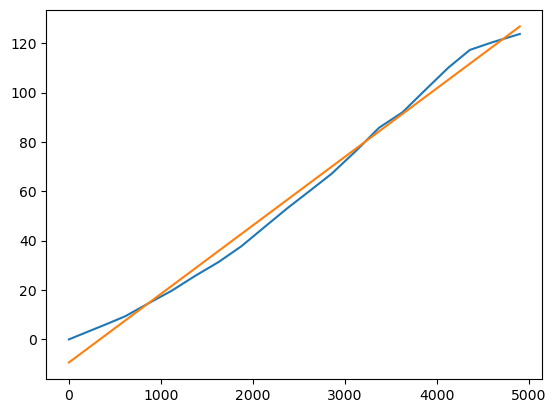

In [3]:
i = 0
print(configs[0]['timing']['tag'])
[(k, times[i][k].shape) for k in times[i].keys()]
energy = times[i]['cond'][:, 0]
pts = times[i]['points']       # shape (n_points,)


n_bins = 20
points_bin_edges = np.linspace(0, 5_000, n_bins + 1)
mean_points = np.zeros(n_bins)
mean_energies = np.zeros(n_bins)
for i in range(1, n_bins):
    mask = (pts > points_bin_edges[i]) * (pts< points_bin_edges[i+1])
    mean_energies[i] = np.nanmean(energy[mask])
    mean_points[i] = np.nanmean(pts[mask])
plt.plot(mean_points, mean_energies)
linear_grad, linear_bias = np.polyfit(mean_points, mean_energies, 1)
plt.plot(mean_points, linear_bias+linear_grad*mean_points)

fwd = lambda x: linear_grad * x + linear_bias
inv = lambda y: (y - linear_bias) / linear_grad

No padded photons v1


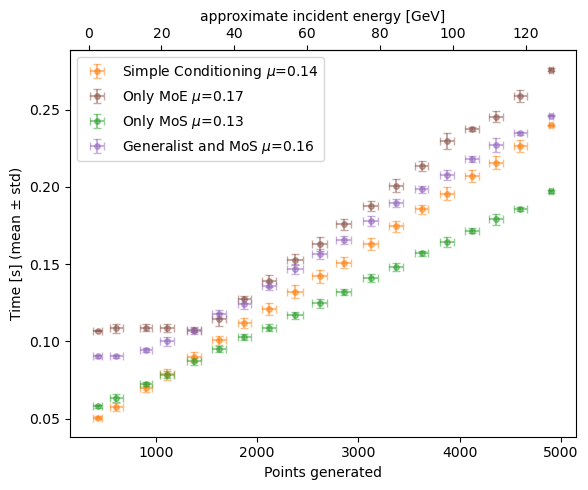

In [5]:
# Use the pre-defined bin edges to cluster points and compute binned statistics


points_bin_edges = np.linspace(0, 5_000, 21)



# Digitize points into bins (1-indexed bins)
fig, ax = plt.subplots(figsize=(6, 5))


for i in range(len(times)):
    device = configs[i]['timing']['device']
    if 'cuda' not in device:
        continue
    tag = configs[i]['timing']['tag'].replace("_", " ")
    if tag not in colours:
        print(f"No {tag}")
        continue
    colour = colours[tag]
    part = configs[i]["timing"]['version']
    if not part == "teacher":
        continue
    name = pretty_names[tag]
    if "Generalist and MoE" in name:
        continue
    t = times[i]['times']          # shape (n_points, n_repetitions)
    pts = times[i]['points']       # shape (n_points,)
    bin_indices = np.digitize(pts, points_bin_edges) - 1  # 0-indexed

    bin_centers = []
    bin_xerr = []
    bin_mean_times = []
    bin_std_times = []
    
    for b in range(n_bins):
        mask = bin_indices == b
        if np.sum(mask) == 0:
            continue
        pts_in_bin = pts[mask]
        times_in_bin = t[mask]  # shape (n_in_bin, n_repetitions)
        
        # x position: mean of points in bin
        x_mean = np.mean(pts_in_bin)
        # x error: standard deviation of points in bin (or half bin width)
        x_std = np.std(pts_in_bin)
        
        # y: mean of all time measurements in this bin
        y_mean = np.mean(times_in_bin)
        # y error: standard deviation of all time measurements in this bin
        y_std = np.std(times_in_bin)
        
        bin_centers.append(x_mean)
        bin_xerr.append(x_std)
        bin_mean_times.append(y_mean)
        bin_std_times.append(y_std)
    
    bin_centers = np.array(bin_centers)
    bin_xerr = np.array(bin_xerr)
    bin_mean_times = np.array(bin_mean_times)
    bin_std_times = np.array(bin_std_times)
    name += f" $\\mu$={np.mean(bin_mean_times):.2}"
    ax.errorbar(bin_centers, bin_mean_times, color=colour,
                xerr=bin_xerr, yerr=bin_std_times,
                fmt='o', capsize=3, markersize=4, alpha=0.5,
                label=name)
ax.set_xlabel('Points generated')
ax.set_ylabel('Time [s] (mean ± std)')
#ax.set_title('Timing vs Points (binned)')

secax = ax.secondary_xaxis('top', functions=(fwd, inv))
secax.set_xlabel("approximate incident energy [GeV]")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(img_dir, "Timing_teachers_reg.pdf"))


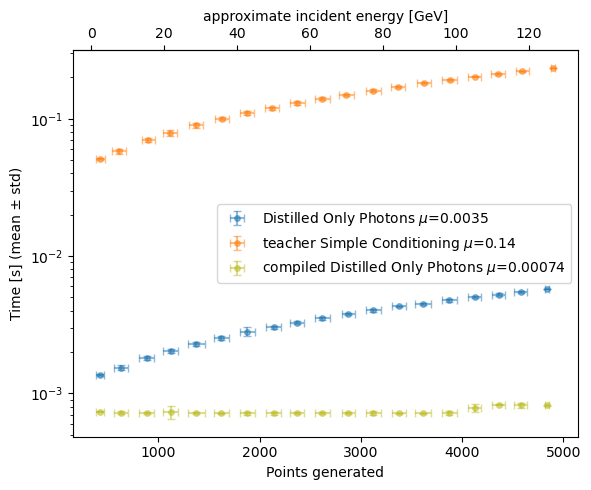

In [5]:
# Use the pre-defined bin edges to cluster points and compute binned statistics


points_bin_edges = np.linspace(0, 5_000, 21)



# Digitize points into bins (1-indexed bins)
fig, ax = plt.subplots(figsize=(6, 5))


for i in range(len(times)):
    device = configs[i]['timing']['device']
    if 'cuda' not in device:
        continue
    tag = configs[i]['timing']['tag'].replace("_", " ")
    colour = colours[tag]
    part = configs[i]["timing"]['version']
    if part == "student":
        part = "Distilled"
    name = pretty_names[tag]
    if part == "teacher" and name != "Simple Conditioning":
        continue
    name = part + " " + name
    t = times[i]['times']          # shape (n_points, n_repetitions)
    pts = times[i]['points']       # shape (n_points,)
    bin_indices = np.digitize(pts, points_bin_edges) - 1  # 0-indexed

    bin_centers = []
    bin_xerr = []
    bin_mean_times = []
    bin_std_times = []
    
    for b in range(n_bins):
        mask = bin_indices == b
        if np.sum(mask) == 0:
            continue
        pts_in_bin = pts[mask]
        times_in_bin = t[mask]  # shape (n_in_bin, n_repetitions)
        
        # x position: mean of points in bin
        x_mean = np.mean(pts_in_bin)
        # x error: standard deviation of points in bin (or half bin width)
        x_std = np.std(pts_in_bin)
        
        # y: mean of all time measurements in this bin
        y_mean = np.mean(times_in_bin)
        # y error: standard deviation of all time measurements in this bin
        y_std = np.std(times_in_bin)
        
        bin_centers.append(x_mean)
        bin_xerr.append(x_std)
        bin_mean_times.append(y_mean)
        bin_std_times.append(y_std)
    
    bin_centers = np.array(bin_centers)
    bin_xerr = np.array(bin_xerr)
    bin_mean_times = np.array(bin_mean_times)
    bin_std_times = np.array(bin_std_times)
    name += f" $\\mu$={np.mean(bin_mean_times):.2}"
    ax.errorbar(bin_centers, bin_mean_times, color=colour,
                xerr=bin_xerr, yerr=bin_std_times,
                fmt='o', capsize=3, markersize=4, alpha=0.5,
                label=name)
ax.set_xlabel('Points generated')
ax.set_ylabel('Time [s] (mean ± std)')
#ax.set_title('Timing vs Points (binned)')

secax = ax.secondary_xaxis('top', functions=(fwd, inv))
secax.set_xlabel("approximate incident energy [GeV]")
ax.legend()
plt.tight_layout()
plt.semilogy()
plt.savefig(os.path.join(img_dir, "Timing_optimisations_reg.pdf"))


In [6]:
configs[i]['timing']

{'batch_size': 16,
 'device': 'cuda',
 'tag': 'distilled_2_from_padded_photons_v1',
 'version': 'compiled'}